# Conti Social Graph Structure Analysis

This notebook analyzes the structure of the Conti communication graph derived from valid conversation units. It loads the saved graph, computes graph-level and node-level measures, clusters users based on network metrics, assigns cluster labels to graph nodes, and saves the clustered graph for visualization and reproducibility.

In [ ]:
# These cells are environment-specific and may need to be adjusted or skipped when running locally.
from google.colab import drive
drive.mount('/content/drive')
#! pip install igraph

Mounted at /content/drive


## Load conversation graph

This section loads the previously saved conversation-unit graph. In this graph, nodes represent Conti users, edges represent reciprocal communication histories, and edge weights represent the number of conversation units between users.

In [ ]:
import networkx as nx
import functions as f

G = f.load_graph('convo_graph.pkl')
G.graph['name'] = 'conti valid conversation units'

In [ ]:
import graph_functions as gf

gf.graph_summary(G)

Number of Nodes: 301
Number of Edges: 1456
Average Degree: 9.67
Maximum Degree: 145
Minimum Degree: 1
Average Weighted Degree: 126.50
Maximum Weighted Degree: 4227
Minimum Weighted Degree: 1
Total Edge Weight: 19039
Number of Connected Components: 1
Average Shortest Path (largest CC): 2.56
Density: 0.03
Diameter: 44
Average Clustering Coefficient: 0.43


## Compute node-level structural measures and message-based metrics

This section calculates node-level network measures such as degree, weighted degree, betweenness centrality, closeness centrality, eigenvector centrality, clustering coefficient, and eccentricity. These measures are used as features for structural clustering.

Then adds message- or conversation-derived metrics to each node. These attributes help describe users not only by graph topology but also by their volume of interaction in the communication network.

In [ ]:
# Calculate and store network measures in the graph G
gf.calculate_node_graph_measures(G)
print("Node attributes for 'baget':", G.nodes['baget'])


Network measures calculated and stored as node attributes.
Node attributes for 'baget': {'w_clustering_coefficient': 0.014227611566793948, 'clustering_coefficient': 0.4329004329004329, 'w_betweenness_centrality': 0.014871970456369425, 'betweenness_centrality': 0.0017964559910979441, 'w_degree': 541, 'degree': 0.07333333333333333, 'w_closeness_centrality': 0.1668520578420467, 'closeness_centrality': 0.46511627906976744, 'w_eigenvector_centrality': 0.04885621822934099, 'eigenvector_centrality': 0.09324176314813065, 'w_eccentricity': 32, 'eccentricity': 4, 'w_load_centrality': 0.014616065898674594, 'load_centrality': 0.0018629870028086435, 'harmonic_centrality': 150.16666666666663, 'w_percolation_centrality': 0.014871970456369413, 'percolation_centrality': 0.0017964559910979428}


In [ ]:
# Calculate and add metrics to the graph
gf.calculate_node_msg_metrics(G)
print("Node attributes for 'baget':", G.nodes['baget'])


Node metrics calculated and added as node attributes.
Node attributes for 'baget': {'w_clustering_coefficient': 0.014227611566793948, 'clustering_coefficient': 0.4329004329004329, 'w_betweenness_centrality': 0.014871970456369425, 'betweenness_centrality': 0.0017964559910979441, 'w_degree': 541, 'degree': 0.07333333333333333, 'w_closeness_centrality': 0.1668520578420467, 'closeness_centrality': 0.46511627906976744, 'w_eigenvector_centrality': 0.04885621822934099, 'eigenvector_centrality': 0.09324176314813065, 'w_eccentricity': 32, 'eccentricity': 4, 'w_load_centrality': 0.014616065898674594, 'load_centrality': 0.0018629870028086435, 'harmonic_centrality': 150.16666666666663, 'w_percolation_centrality': 0.014871970456369413, 'percolation_centrality': 0.0017964559910979428, 'messages_sent': 3117, 'messages_received': 1844, 'avg_convo_length': np.float64(9.170055452865064), 'avg_response_time': np.float64(130.50023230482898), 'lifespan': 52954662.509361}


## Prepare node features, test clustering solutions, apply GMM clustering and visualize the results

This section extracts numeric node attributes into a feature matrix and evaluates clustering solutions. Several clustering and preprocessing choices are explored to identify a stable and interpretable grouping of users based on structural position.

In the final results log-transforms skewed network metrics, standardizes the feature matrix, and applies Gaussian Mixture Model clustering. The resulting clusters represent structural tiers of users based on their positions in the communication network.

Explained variance by 2 components: 68.95%
Explained variation per principal component: [0.51121119 0.17831025]

PCA Component Loadings:
       w_clustering_coefficient  clustering_coefficient  \
PC_1                  0.040901                0.060349   
PC_2                  0.599053                0.568776   

      w_betweenness_centrality  betweenness_centrality  w_degree    degree  \
PC_1                  0.311700                0.299328  0.331776  0.376216   
PC_2                  0.204216                0.201139  0.252179  0.124159   

      w_closeness_centrality  closeness_centrality  w_eigenvector_centrality  \
PC_1                0.258749              0.359688                  0.305940   
PC_2                0.170848              0.200573                  0.047172   

      eigenvector_centrality  w_eccentricity  eccentricity  
PC_1                0.389928        0.211658      0.263720  
PC_2                0.012764        0.186197      0.223566  


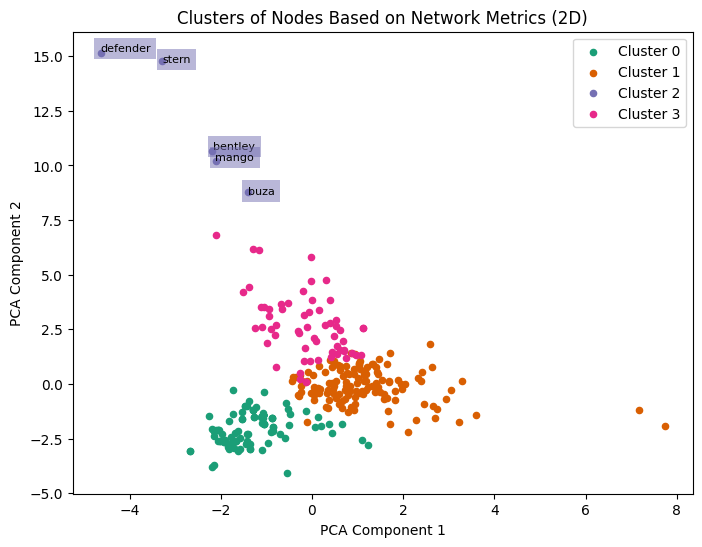

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn import metrics
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt
import random

# Extract all numeric attributes as features for clustering
def extract_features(G, exclude_attrs=None):
    if exclude_attrs is None:
        exclude_attrs = []

    data = []
    nodes = list(G.nodes())

    # Get all attribute names by looking at the first node's attributes and exclude specified ones
    sample_node = nodes[0]
    feature_names = [
        key for key, value in G.nodes[sample_node].items()
        if isinstance(value, (int, float)) and key not in exclude_attrs
    ]

    # Extract features for each node, excluding the specified attributes
    for node in nodes:
        data.append([G.nodes[node].get(attr, 0) for attr in feature_names])

    # Convert to DataFrame for easy manipulation and inspection
    features_df = pd.DataFrame(data, index=nodes, columns=feature_names)
    return features_df

def apply_pca(features_df, n_components=2):
    # Normalize features and apply PCA
    # power_transformer = PowerTransformer() # for transofrming skewed features
    # transformed_skewed = power_transformer.fit_transform(features_df)

    # 1. Apply log(x + 1) transform to skewed features
    log_features_df = features_df.apply(lambda x: np.log1p(x))
    scaler = StandardScaler()
    features_normalized = scaler.fit_transform(log_features_df)

    # scaler = MinMaxScaler()
    # features_normalized = scaler.fit_transform(features_df)

    pca = PCA(n_components=n_components)
    reduced_data = pca.fit_transform(features_normalized)

    # Print explained variance
    explained_variance = np.sum(pca.explained_variance_ratio_)
    print(f'Explained variance by {n_components} components: {explained_variance:.2%}')
    print(f'Explained variation per principal component: {pca.explained_variance_ratio_}')

    # Display component loadings for each feature
    component_names = [f'PC_{i+1}' for i in range(n_components)]
    dataset_pca = pd.DataFrame(abs(pca.components_), columns=features_df.columns, index=component_names)
    print('\nPCA Component Loadings:\n', dataset_pca)

    return reduced_data, features_normalized

def kmeans_clustering(features_df, reduced_data, n_clusters=3):
    # Perform K-Means clustering on PCA-reduced data
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(reduced_data)
    features_df['cluster'] = cluster_labels  # Add cluster labels to the DataFrame

    return features_df

def gmm_clustering(features_df, reduced_data, n_clusters=3):
    # Perform Gaussian Mixture Model clustering on PCA-reduced data
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    cluster_labels = gmm.fit_predict(reduced_data)
    features_df['cluster'] = cluster_labels  # Add cluster labels to the DataFrame

    return features_df

def generate_colors(n_clusters):
    # Choose a qualitative colormap
    cmap = plt.get_cmap('Dark2')

    # Generate a list of colors based on the number of clusters
    colors = [cmap(i) for i in range(n_clusters)]
    return colors

def visualize_clusters(reduced_data, labels, clustered_features_df, n_clusters=3):
    # Generate a list of distinct colors for the clusters
    colors = generate_colors(n_clusters)

    # Identify clusters with fewer than 10 members
    cluster_sizes = clustered_features_df['cluster'].value_counts()
    small_clusters = cluster_sizes[cluster_sizes < 10].index

    if reduced_data.shape[1] == 2:
        plt.figure(figsize=(8, 6))
        for i in range(n_clusters):
            cluster_points = reduced_data[labels == i]
            plt.scatter(cluster_points[:, 1],cluster_points[:, 0], color=colors[i], label=f'Cluster {i}', s=20)

            # Label points in clusters with fewer than 10 members
            if i in small_clusters:
                for j, point in enumerate(cluster_points):
                    # Retrieve the index of the point in the original DataFrame
                    row_id = clustered_features_df[clustered_features_df['cluster'] == i].index[j]
                    # Offset randomly
                    plt.text( point[1] + random.uniform(-0.05, 0.05),point[0] + random.uniform(-0.1, 0.1), str(row_id), fontsize=8, color='black',
                             bbox=dict(facecolor=colors[i], edgecolor='none', alpha=0.5))

        plt.xlabel("PCA Component 1")
        plt.ylabel("PCA Component 2")
        plt.title("Clusters of Nodes Based on Network Metrics (2D)")
        plt.legend()

    elif reduced_data.shape[1] == 3:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        for i in range(n_clusters):
            cluster_points = reduced_data[labels == i]
            ax.scatter(cluster_points[:, 2], cluster_points[:, 0], cluster_points[:, 1],
                       color=colors[i], label=f'Cluster {i}', s=20)

            # Label points in clusters with fewer than 10 members
            if i in small_clusters:
                for j, point in enumerate(cluster_points):
                    # Retrieve the index of the point in the original DataFrame
                    row_id = clustered_features_df[clustered_features_df['cluster'] == i].index[j]
                    # Offset randomly
                    ax.text(point[2] + random.uniform(0.05, 0.2), point[0] + random.uniform(0.05, 0.2), point[1] + random.uniform(0.05, 0.2), str(row_id), fontsize=8, color='black',
                            bbox=dict(facecolor=colors[i], edgecolor='none', alpha=0.5))

        ax.set_xlabel("PCA Component 1")
        ax.set_ylabel("PCA Component 2")
        ax.set_zlabel("PCA Component 3")
        ax.set_title("Clusters of Nodes Based on Network Metrics (3D)")
        ax.legend(loc='upper right', bbox_to_anchor=(0.8, 0.8), fontsize=8, frameon=True, edgecolor='gray', fancybox=False, shadow=False)
        # Rotate the 3D plot
        ax.view_init(elev=40, azim=-40)
        plt.tight_layout()
    plt.show()


exclude_attributes = ['avg_convo_length', 'messages_sent', 'messages_received',
                      'avg_response_time', 'lifespan',
                      'normalized_eccentricity','normalized_weighted_degree', 'hub_score',
                      'harmonic_centrality', 'load_centrality', 'w_load_centrality', 'w_percolation_centrality', 'percolation_centrality']

features_df = extract_features(G, exclude_attributes)
reduced_data, features_normalized = apply_pca(features_df, n_components=2)
n_clusters = 4


# Gaussian Mixture Model clustering
clustered_features_df = gmm_clustering(features_df, features_normalized, n_clusters=n_clusters)

visualize_clusters(reduced_data, clustered_features_df['cluster'], clustered_features_df, n_clusters=n_clusters)

Computed model-selection diagnostics across different numbers of clusters, including AIC, BIC, silhouette score, and Calinski-Harabasz score. These metrics support the final choice of the number of structural clusters n_clusters = 4

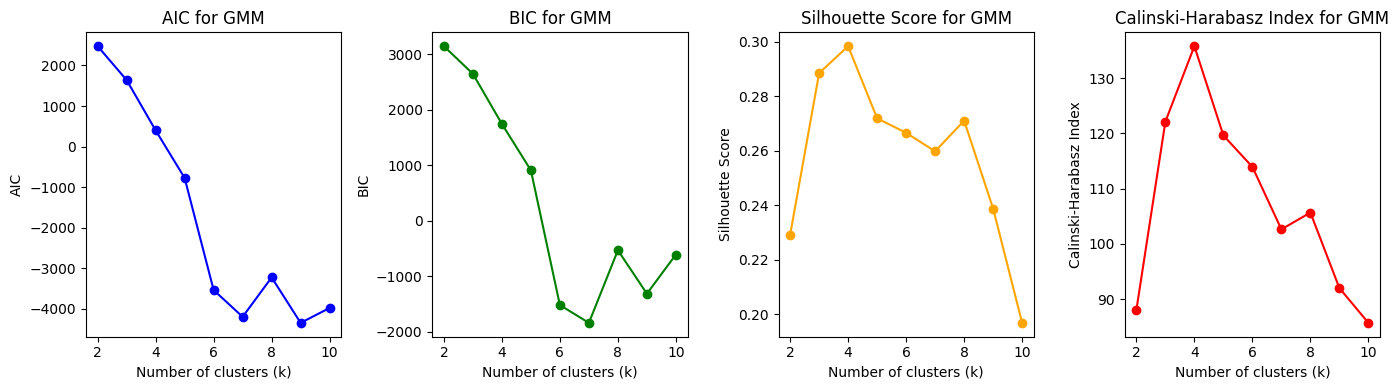

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
import matplotlib.pyplot as plt

def plot_clustering_metrics(features_df, max_k=10, method='kmeans'):
    k_values = range(2, max_k + 1)  # Start from 2 clusters as Silhouette requires at least 2

    # Initialize metric lists based on method
    inertia = [] if method == 'kmeans' else None
    silhouette_scores = []
    aic = [] if method == 'gmm' else None
    bic = [] if method == 'gmm' else None
    chi = [] if method == 'gmm' else None

    for k in k_values:
        if method == 'kmeans':
            # K-Means clustering
            model = KMeans(n_clusters=k, n_init=20, random_state=42)
            model.fit(features_df)

            # Collect metrics
            inertia.append(model.inertia_)
            silhouette_scores.append(silhouette_score(features_df, model.labels_))

        elif method == 'gmm':
            # Gaussian Mixture Model clustering
            model = GaussianMixture(n_components=k, random_state=42)
            model.fit(features_df)

            # Collect metrics
            aic.append(model.aic(features_df))
            bic.append(model.bic(features_df))
            silhouette_scores.append(silhouette_score(features_df, model.predict(features_df)))
            chi.append(calinski_harabasz_score(features_df, model.predict(features_df)))

    # Plot metrics based on the method
    plt.figure(figsize=(14, 4))
    if method == 'kmeans':
        # Plot Inertia (SSE)
        plt.subplot(1, 2, 1)
        plt.plot(k_values, inertia, marker='o', color='blue')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("Inertia (SSE)")
        plt.title("Inertia (SSE) for K-Means")

        # Plot Silhouette Score
        plt.subplot(1, 2, 2)
        plt.plot(k_values, silhouette_scores, marker='o', color='orange')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("Silhouette Score")
        plt.title("Silhouette Score for K-Means")

    elif method == 'gmm':
        # Plot AIC
        plt.subplot(1, 4, 1)
        plt.plot(k_values, aic, marker='o', color='blue')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("AIC")
        plt.title("AIC for GMM")

        # Plot BIC
        plt.subplot(1, 4, 2)
        plt.plot(k_values, bic, marker='o', color='green')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("BIC")
        plt.title("BIC for GMM")

        # Plot Silhouette Score
        plt.subplot(1, 4, 3)
        plt.plot(k_values, silhouette_scores, marker='o', color='orange')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("Silhouette Score")
        plt.title("Silhouette Score for GMM")

        # Plot Calinski-Harabasz Index
        plt.subplot(1, 4, 4)
        plt.plot(k_values, chi, marker='o', color='red')
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("Calinski-Harabasz Index")
        plt.title("Calinski-Harabasz Index for GMM")

    plt.tight_layout()
    plt.show()


# For GMM
plot_clustering_metrics(features_normalized, max_k=10, method='gmm')


In [ ]:
clustered_features_df

,w_clustering_coefficient,clustering_coefficient,w_betweenness_centrality,betweenness_centrality,w_degree,degree,w_closeness_centrality,closeness_centrality,w_eigenvector_centrality,eigenvector_centrality,w_eccentricity,eccentricity,cluster
bentley,0.007032,0.164085,0.095887,0.075175,3253,0.280000,0.184049,0.548446,0.534794,0.234529,30,4,2
deploy,0.018144,0.458874,0.031215,0.003513,924,0.073333,0.188679,0.468750,0.332590,0.097438,31,4,3
hof,0.008563,0.293869,0.107611,0.012038,755,0.146667,0.189873,0.496689,0.150810,0.157592,29,4,3
mors,0.039268,0.733333,0.000000,0.000251,440,0.033333,0.141911,0.451128,0.124703,0.061276,33,4,1
frog,0.035124,0.785714,0.000000,0.000165,201,0.026667,0.125000,0.450450,0.042390,0.053848,34,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
beny,0.000000,0.000000,0.000000,0.000000,1,0.003333,0.146843,0.328587,0.000038,0.003791,32,5,0
billgeizh,0.000000,0.000000,0.000000,0.000000,1,0.003333,0.152053,0.362757,0.000186,0.008031,32,4,0
def,0.000000,0.000000,0.000000,0.000000,1,0.003333,0.131579,0.292398,0.000005,0.000991,33,5,0
fury,0.000000,0.000000,0.000000,0.000000,1,0.003333,0.149105,0.337079,0.000054,0.005120,33,4,0


In [ ]:
# Assign cluster labels to nodes in the graph G
for node in clustered_features_df.index:
    cluster_label = clustered_features_df.loc[node, 'cluster']
    G.nodes[node]['gmm_cluster'] = cluster_label  # Set the cluster label as a node attribute in G

# Group nodes by cluster and create a distribution
cluster_distribution = clustered_features_df['cluster'].value_counts()
print("Cluster Distribution:\n", cluster_distribution)

# List node IDs in each cluster
nodes_in_clusters = clustered_features_df.groupby('cluster').apply(lambda x: list(x.index))
print("\nNodes in Each Cluster:")
for cluster, nodes in nodes_in_clusters.items():
    print(f"Cluster {cluster}: {nodes}")


Cluster Distribution:
 cluster
1    133
0    103
3     60
2      5
Name: count, dtype: int64

Nodes in Each Cluster:
Cluster 0: ['xenon', 'netman', 'impact', 'blackjob', 'wowddoz', 'david', 'steve', 'sega', 'muchacho', 'cobdoctor', 'oldtimes', 'qwerty', 'sentinel', 'tiniles', 'taur', 'gentleman', 'salmon', 'pincus', 'muhoboi', 'moms', 'longer', 'marcus', 'moon', 'matiz', 'olsen', 'summit', 'werka', 'log', 'song', 'hitech', 'huanivan', 'merlin', 'shaper', 'sirafim', 'forus', 'sharn', 'tatarin', 'starfall', 'ololoenko', 'qwertycatt', 'quite', 'tnt', 'xmoney', 'noman', 'alert', 'cuba', 'baxter', 'buggati', 'calmar', 'urban', 'ahtyng', 'project_talk', 'expex', 'casper', 'admin', 'boba', 'jora', 'santi', 'snow', 'valemy', 'master', 'koncord', 'mavalek', 'sepvilk', 'good_place', 'ahtung', 'admu', 'duke', 'macallan', 'ed', 'tort', 'glad', 'serp', 'mitzi', 'dylan', 'nuggets', 'firefox333', 'fog', 'b2zbrzj5sljbmemgfqnn7zlarduyjhvjwt', 'golova', 'blood', 'morisson', 'answer', 'romanov_2', 'freeb

<ipython-input-32-078c154f722d>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nodes_in_clusters = clustered_features_df.groupby('cluster').apply(lambda x: list(x.index))


In [ ]:
import graph_functions as gf
gf.save_graph(G, 'conti_clusters.pkl')

# Clean the graph for GraphML compatibility
G_cleaned = gf.clean_graph_for_graphml(G)

# Save the cleaned graph as GraphML
nx.write_graphml(G_cleaned, "graph_clusters.graphml")



Graph saved as conti_clusters.pkl
